# Exploratory Data Analysis and Feature Engineering
## Heart Disease Dataset

This project performs:
- Dataset understanding
- Data quality checking
- Missing-value analysis
- Duplicate detection
- Validity and range checking
- Univariate analysis
- Bivariate analysis
- Correlation analysis
- Outlier analysis
- Data cleaning
- Feature engineering
- Final validation


## Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
df = pd.read_csv("Heart.csv")

## Dataset Samples

In [4]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [89]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [90]:
df.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
566,41,M,ASY,150,171,0,Normal,128,Y,1.5,Flat,0
146,42,M,ATA,120,198,0,Normal,155,N,0.0,Up,0
138,54,M,ASY,140,166,0,Normal,118,Y,0.0,Flat,1
131,46,M,ASY,110,202,0,Normal,150,Y,0.0,Flat,1
909,63,F,ASY,124,197,0,Normal,136,Y,0.0,Flat,1


## Dataset Information

In [91]:
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape: (918, 12)
Rows: 918
Columns: 12


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [93]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [95]:
df.describe(include=["object","str"])


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


## Missing Values

In [96]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

There are no empty/null values in the raw dataset.


## Duplicate Rows

In [97]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Unique Values

In [98]:
df.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

## Numerical and Categorical Columns

In [100]:
numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include=["object","str"]).columns
print("Numerical Columns:")
print(list(numerical_columns))
print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

Categorical Columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


## Category Checks

In [102]:
expected_categories = {
    "Sex": {"M", "F"},
    "ChestPainType": {"ATA", "NAP", "ASY", "TA"},
    "RestingECG": {"Normal", "ST", "LVH"},
    "ExerciseAngina": {"Y", "N"},
    "ST_Slope": {"Up", "Flat", "Down"}
}

for column, expected in expected_categories.items():
    actual = set(df[column].dropna().unique())
    print(column, ":", actual)
    print("Unexpected:", actual - expected)


Sex : {'F', 'M'}
Unexpected: set()
ChestPainType : {'TA', 'NAP', 'ASY', 'ATA'}
Unexpected: set()
RestingECG : {'ST', 'Normal', 'LVH'}
Unexpected: set()
ExerciseAngina : {'Y', 'N'}
Unexpected: set()
ST_Slope : {'Down', 'Up', 'Flat'}
Unexpected: set()


In [104]:
print("FastingBS values:", sorted(df["FastingBS"].unique()))
print("HeartDisease values:", sorted(df["HeartDisease"].unique()))

FastingBS values: [np.int64(0), np.int64(1)]
HeartDisease values: [np.int64(0), np.int64(1)]


## Numerical Range Checks

In [5]:
range_check = df[[ "Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]].agg(["min", "max"])
range_check

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
min,28,0,0,0,60,-2.6
max,77,200,603,1,202,6.2


## Data Quality Checks

In [109]:
print("RestingBP = 0:", (df["RestingBP"] == 0).sum())
print("Cholesterol = 0:", (df["Cholesterol"] == 0).sum())
print("FastingBS = 0:", (df["FastingBS"] == 0).sum())
print("Negative Oldpeak:", (df["Oldpeak"] < 0).sum())


RestingBP = 0: 1
Cholesterol = 0: 172
FastingBS = 0: 704
Negative Oldpeak: 13


The zero values in RestingBP and Cholesterol are treated as invalid measurements. FastingBS uses 0 and 1 as valid binary values.
Negative Oldpeak values are flagged.


## Heart Disease Distribution

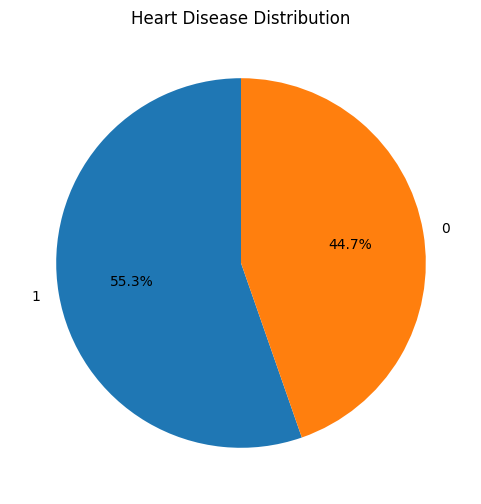

In [164]:
plt.figure(figsize=(6, 6))
df["HeartDisease"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Heart Disease Distribution")
plt.show()

##### The dataset contains 508 patients with heart disease and 410 patients without heart disease. The two classes are reasonably close.

In [134]:
target_counts = df["HeartDisease"].value_counts()
print(target_counts)
print((target_counts / len(df) * 100).round(2))

HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    55.34
0    44.66
Name: count, dtype: float64


The target contains 508 patients with heart disease and 410 without heart disease.


## Gender Distribution

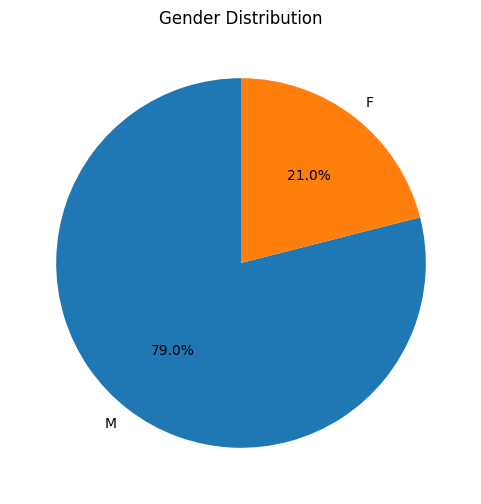

In [167]:
plt.figure(figsize=(6, 6))
df["Sex"].value_counts().plot(kind="pie",autopct="%1.1f%%", startangle=90)
plt.title("Gender Distribution")
plt.show()

#### Male have more heart disease than female and probably of male prominent datset.

## Gender vs Heart Disease

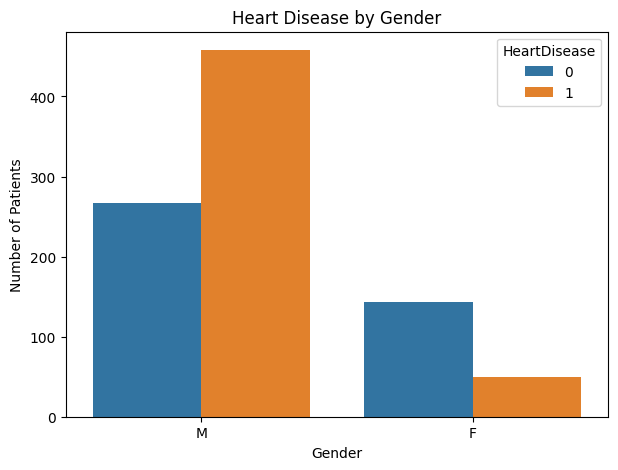

In [168]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex", hue="HeartDisease")
plt.title("Heart Disease by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

##### Heart disease is present in both male and female patients. The number of male patients with heart disease is higher, but this is also affected by the larger number of male patients in the dataset.

In [169]:
gender_target = pd.crosstab(df["Sex"], df["HeartDisease"],normalize="index") * 100
gender_target.round(2)

HeartDisease,0,1
Sex,,
F,74.09,25.91
M,36.83,63.17


## Chest Pain Type

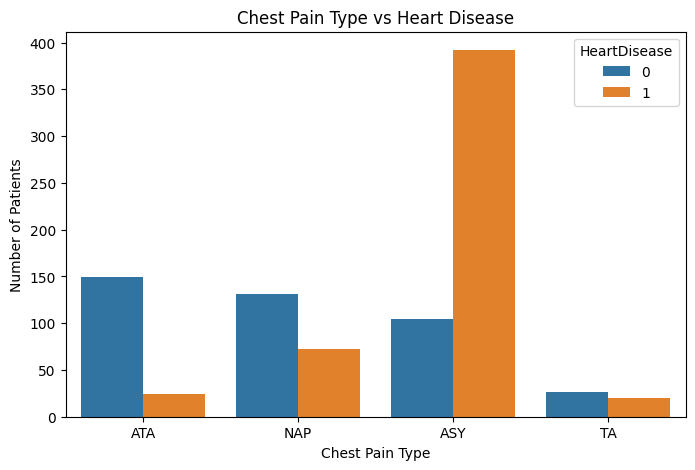

In [170]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="ChestPainType", hue="HeartDisease")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.show()

#### ASY chest pain category have more heart disease

In [171]:
chest_target = pd.crosstab(df["ChestPainType"], df["HeartDisease"], normalize="index") * 100
chest_target.round(2)

HeartDisease,0,1
ChestPainType,,
ASY,20.97,79.03
ATA,86.13,13.87
NAP,64.53,35.47
TA,56.52,43.48


## Other Categorical Features

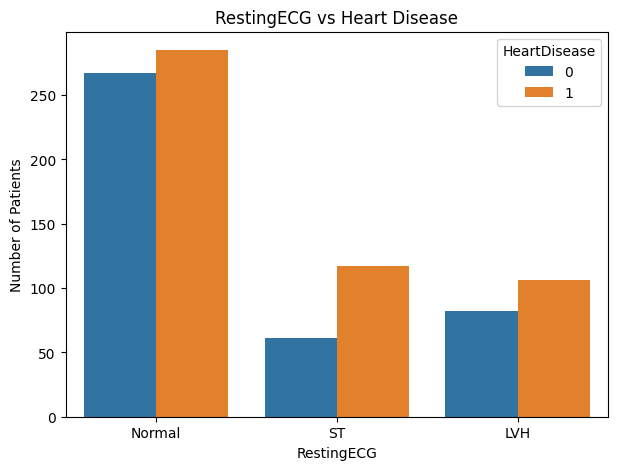

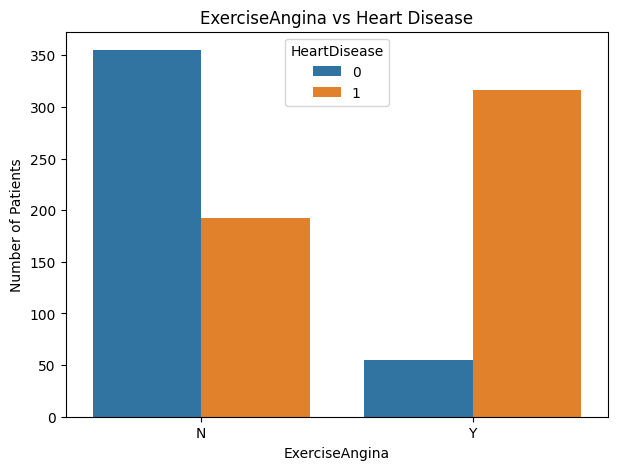

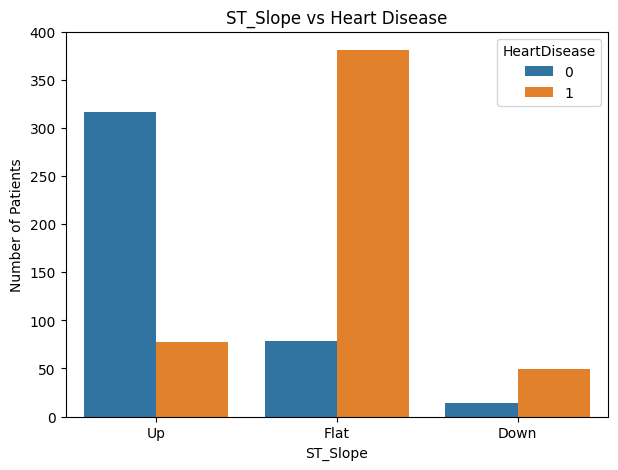

In [172]:
for column in ["RestingECG", "ExerciseAngina", "ST_Slope"]:
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df, x=column, hue="HeartDisease")
    plt.title(f"{column} vs Heart Disease")
    plt.xlabel(column)
    plt.ylabel("Number of Patients")
    plt.show()

##### The distribution of heart disease varies across the RestingECG categories
##### Patients with exercise-induced angina show a different heart disease distribution compared with patients without exercise-induced angina.
##### The Flat category is commonly observed among patients with heart disease.

## Fasting Blood Sugar

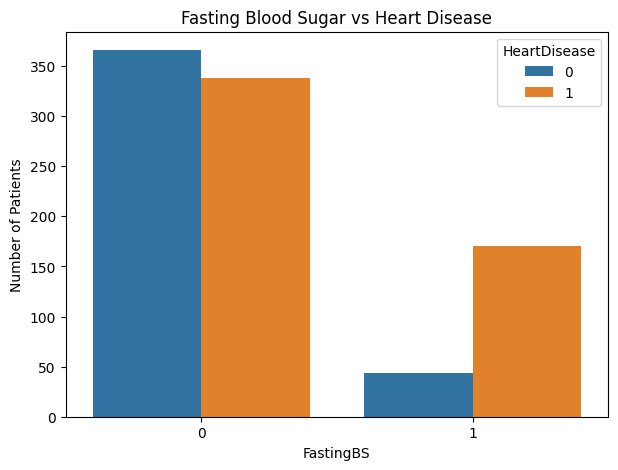

In [173]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="FastingBS", hue="HeartDisease")
plt.title("Fasting Blood Sugar vs Heart Disease")
plt.xlabel("FastingBS")
plt.ylabel("Number of Patients")
plt.show()

##### Most patients have FastingBS equal to 0. The distribution of heart disease is different between the FastingBS categories

## Numerical Features

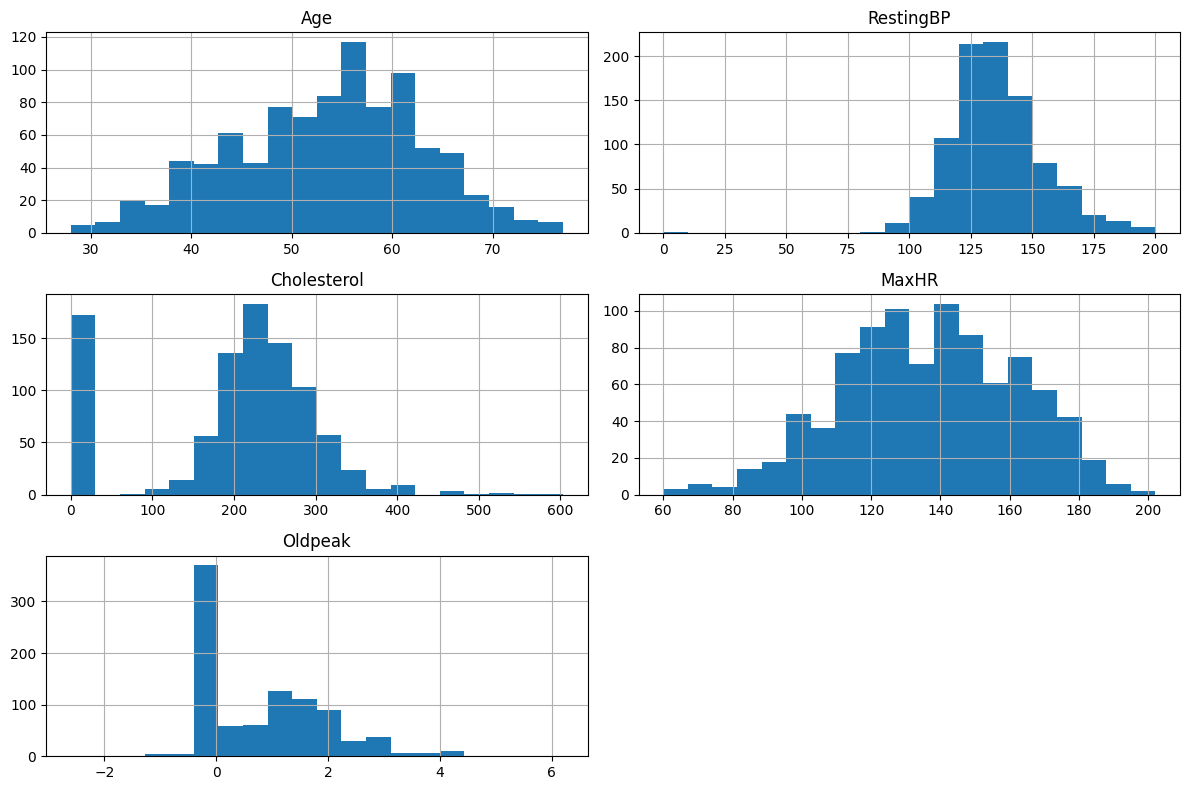

In [174]:
continuous_columns = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
df[continuous_columns].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

##### Age : The age distribution mainly contains middle-aged and older patients.
##### RestingBP : The zero value is an invalid/suspicious observation and needs to be handled during data cleaning.
##### Cholesterol :  A large number of zero values are present, which are treated as invalid measurements and are handled during cleaning.
##### MaxHR : Maximum heart rate varies considerably between patients.
##### Oldpeak : Negative values are flagged for further checking rather than being automatically removed.

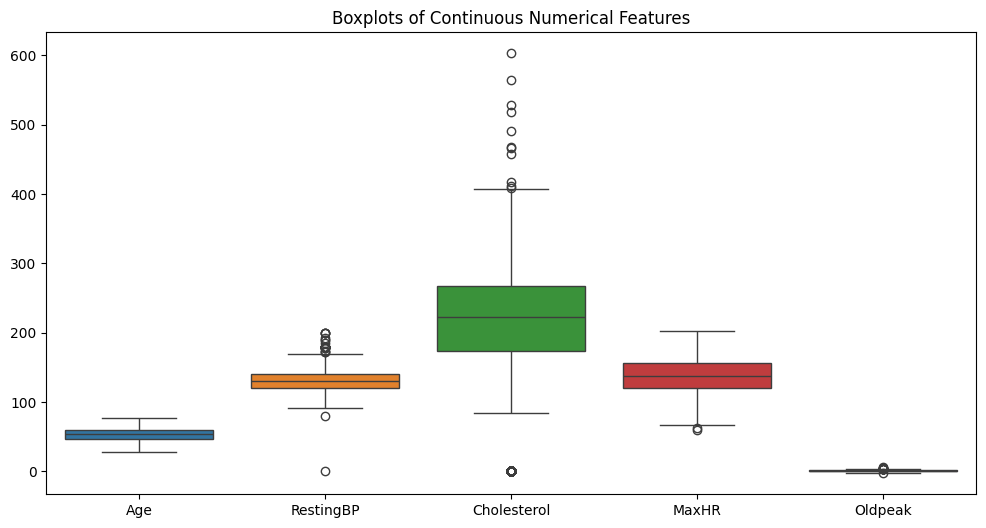

In [175]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[continuous_columns])
plt.title("Boxplots of Continuous Numerical Features")
plt.show()

##### The boxplots show the spread and possible extreme values in the numerical features

## Cholesterol Analysis

In [176]:
print("Cholesterol = 0:", (df["Cholesterol"] == 0).sum())
print("Cholesterol > 240:", (df["Cholesterol"] > 240).sum())
print("Maximum cholesterol:", df["Cholesterol"].max())

Cholesterol = 0: 172
Cholesterol > 240: 355
Maximum cholesterol: 603


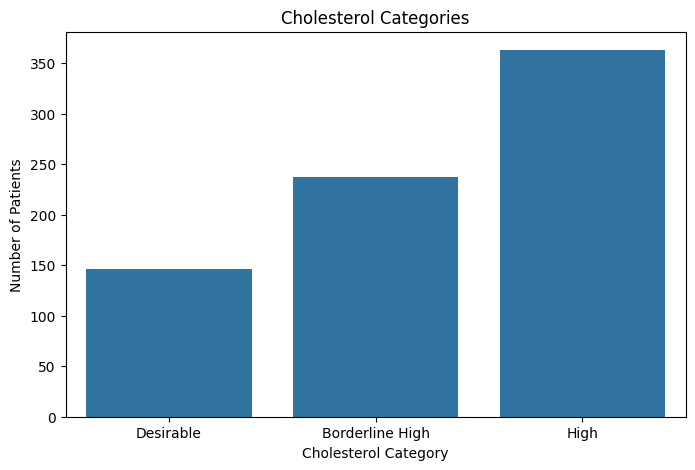

In [180]:
cholesterol_valid = df.loc[df["Cholesterol"] > 0, "Cholesterol"]
cholesterol_category = pd.cut(cholesterol_valid,  bins=[0, 199, 239, np.inf], labels=["Desirable", "Borderline High", "High"])
plt.figure(figsize=(8, 5))
sns.countplot(x=cholesterol_category)
plt.title("Cholesterol Categories")
plt.xlabel("Cholesterol Category")
plt.ylabel("Number of Patients")
plt.show()

##### The cholesterol values are divided into Desirable, Borderline High and High categories

## Blood Pressure Categories

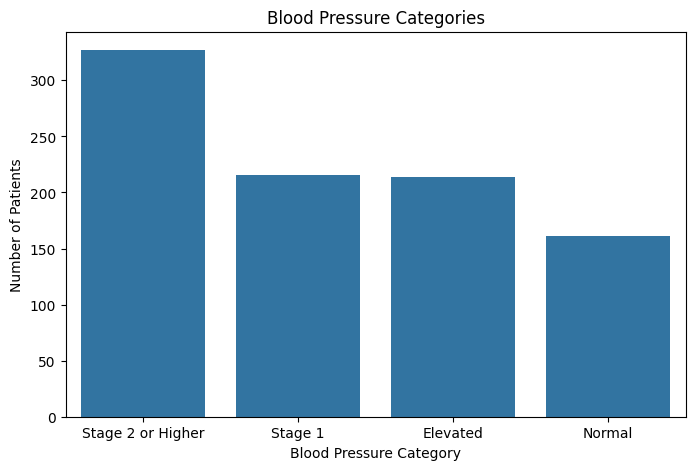

In [181]:
def bp_category(bp):
    if bp < 120:
        return "Normal"
    elif bp < 130:
        return "Elevated"
    elif bp < 140:
        return "Stage 1"
    else:
        return "Stage 2 or Higher"
bp_categories = df["RestingBP"].apply(bp_category)
plt.figure(figsize=(8, 5))
sns.countplot(x=bp_categories)
plt.title("Blood Pressure Categories")
plt.xlabel("Blood Pressure Category")
plt.ylabel("Number of Patients")
plt.show()

##### Patients are distributed across different blood pressure categories.

## Numerical Features vs Heart Disease

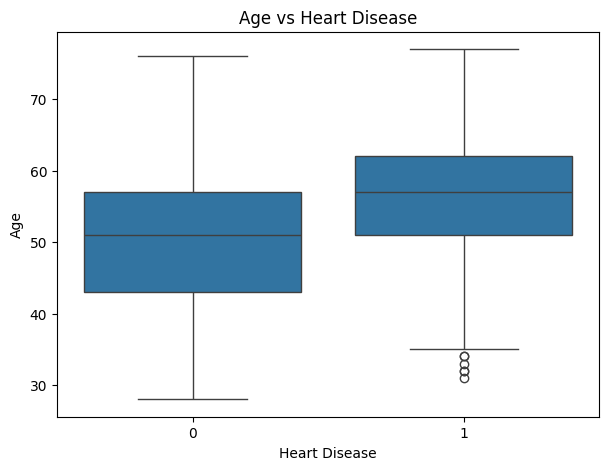

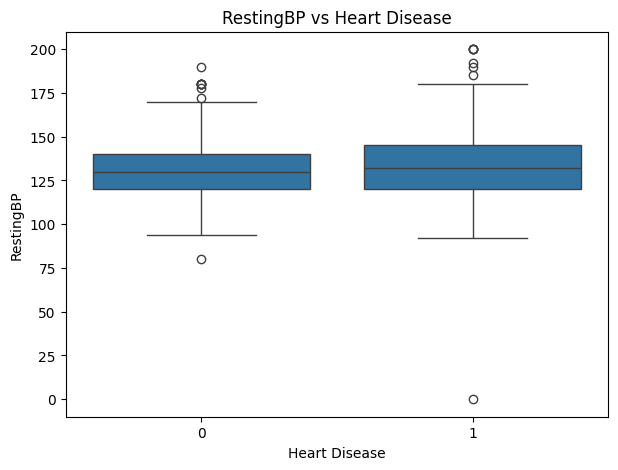

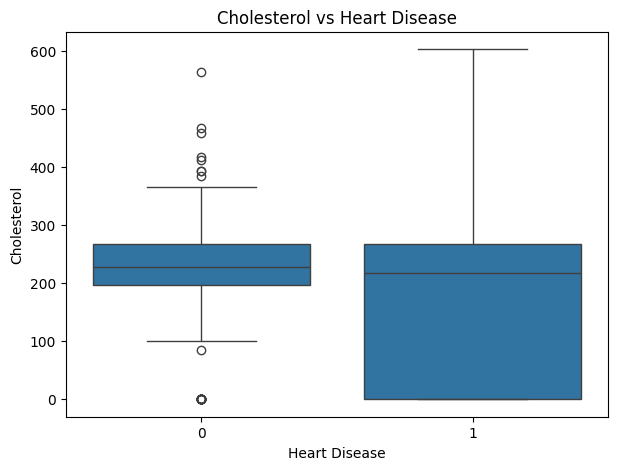

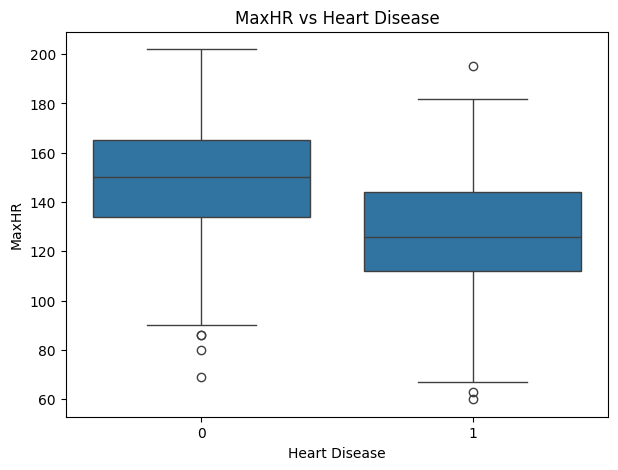

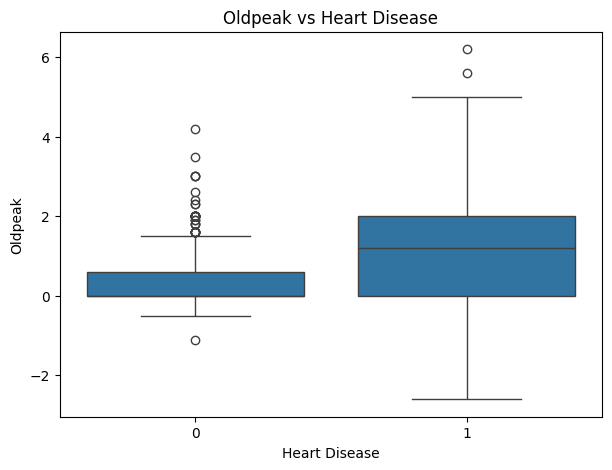

In [182]:
for column in continuous_columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x="HeartDisease", y=column)
    plt.title(f"{column} vs Heart Disease")
    plt.xlabel("Heart Disease")
    plt.ylabel(column)
    plt.show()

##### Age, MaxHR and Oldpeak show noticeable differences between the two groups, while some other features have more overlapping distributions.

## Mean and Median Comparison

In [183]:
df.groupby("HeartDisease")[["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]].agg(["mean", "median"]).round(2)

Age        RestingBP        Cholesterol          MaxHR         \
               mean median      mean median        mean median    mean median   
HeartDisease                                                                    
0             50.55   51.0    130.18  130.0      227.12  227.0  148.15  150.0   
1             55.90   57.0    134.19  132.0      175.94  217.0  127.66  126.0   

             Oldpeak         
                mean median  
HeartDisease                 
0               0.41    0.0  
1               1.27    1.2

## Correlation

In [184]:
correlation = df[["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak", "HeartDisease"]].corr()
correlation.round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.00,0.25,-0.10,0.20,-0.38,0.26,0.28
RestingBP,0.25,1.00,0.10,0.07,-0.11,0.16,0.11
Cholesterol,-0.10,0.10,1.00,-0.26,0.24,0.05,-0.23
FastingBS,0.20,0.07,-0.26,1.00,-0.13,0.05,0.27
MaxHR,-0.38,-0.11,0.24,-0.13,1.00,-0.16,-0.40
Oldpeak,0.26,0.16,0.05,0.05,-0.16,1.00,0.40
HeartDisease,0.28,0.11,-0.23,0.27,-0.40,0.40,1.00


In [37]:
correlation_data = df[[
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "HeartDisease"
]].copy()

correlation_data["RestingBP"] = correlation_data["RestingBP"].replace(0, np.nan)
correlation_data["Cholesterol"] = correlation_data["Cholesterol"].replace(0, np.nan)

correlation = correlation_data.corr()

correlation.round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.00,0.26,0.06,0.20,-0.38,0.26,0.28
RestingBP,0.26,1.00,0.10,0.07,-0.11,0.17,0.12
Cholesterol,0.06,0.10,1.00,0.05,-0.02,0.06,0.10
FastingBS,0.20,0.07,0.05,1.00,-0.13,0.05,0.27
MaxHR,-0.38,-0.11,-0.02,-0.13,1.00,-0.16,-0.40
Oldpeak,0.26,0.17,0.06,0.05,-0.16,1.00,0.40
HeartDisease,0.28,0.12,0.10,0.27,-0.40,0.40,1.00


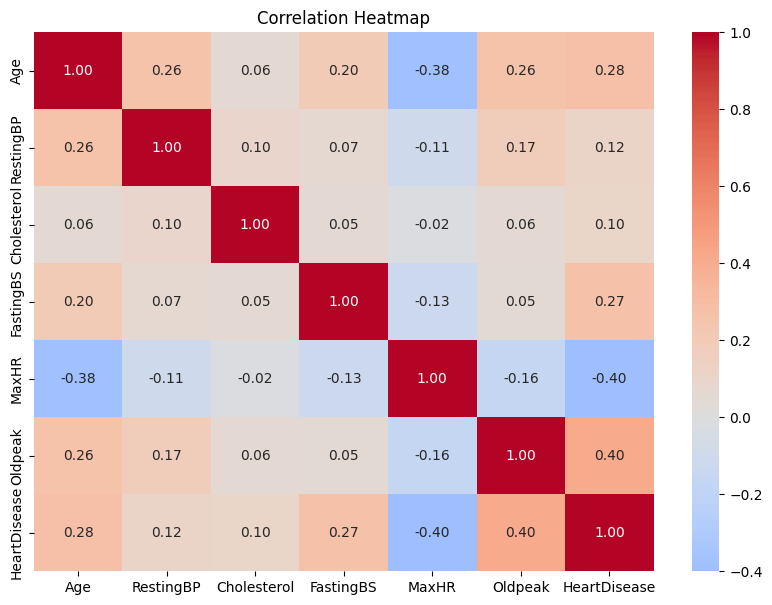

In [38]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

## Correlation with Heart Disease

In [186]:
target_correlation = correlation["HeartDisease"].sort_values(ascending=False)
target_correlation.round(2)

HeartDisease    1.00
Oldpeak         0.40
Age             0.28
FastingBS       0.27
RestingBP       0.11
Cholesterol    -0.23
MaxHR          -0.40
Name: HeartDisease, dtype: float64

## Scatter Plot

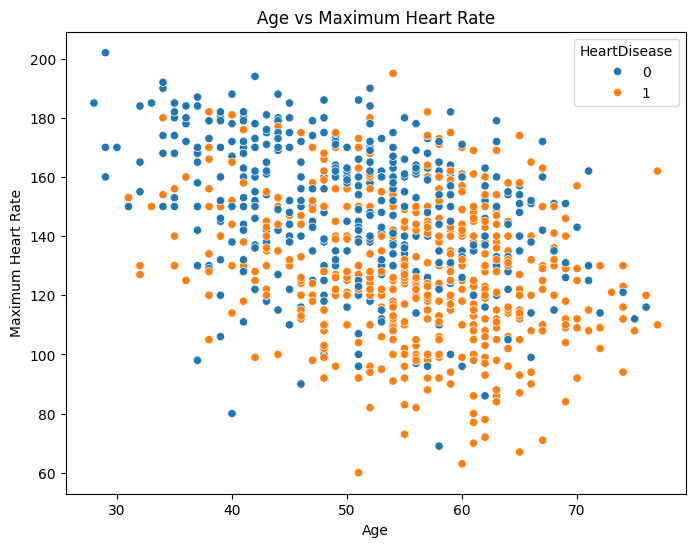

In [187]:
plt.figure(figsize=(8, 6))
sns.scatterplot( data=df, x="Age", y="MaxHR",hue="HeartDisease")
plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.show()

##### The scatter plot shows that maximum heart rate generally tends to decrease as age increases.

## Outlier Detection

In [188]:
outlier_summary = []
for column in continuous_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[column] < lower) | (df[column] > upper)).sum()
    percentage = (count / len(df)) * 100
    outlier_summary.append([column, Q1, Q3, IQR, lower, upper, count, percentage])
outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature", "Q1", "Q3", "IQR",
        "Lower Bound", "Upper Bound",
        "Outlier Count", "Percentage"
        ])
outlier_df.round(2)


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Percentage
0,Age,47.00,60.0,13.00,27.50,79.50,0,0.00
1,RestingBP,120.00,140.0,20.00,90.00,170.00,28,3.05
2,Cholesterol,173.25,267.0,93.75,32.62,407.62,183,19.93
3,MaxHR,120.00,156.0,36.00,66.00,210.00,2,0.22
4,Oldpeak,0.00,1.5,1.50,-2.25,3.75,16,1.74


## Data Cleaning

In [189]:
df_clean = df.copy()
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)
df_clean["RestingBP"] = df_clean["RestingBP"].fillna(df_clean["RestingBP"].median())
df_clean["Cholesterol"] = df_clean["Cholesterol"].fillna(df_clean["Cholesterol"].median())
print(df_clean.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [190]:
print("Zero RestingBP:", (df_clean["RestingBP"] == 0).sum())
print("Zero Cholesterol:", (df_clean["Cholesterol"] == 0).sum())
print("Total missing values:", df_clean.isnull().sum().sum())

Zero RestingBP: 0
Zero Cholesterol: 0
Total missing values: 0


## Feature Engineering

In [191]:
df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],bins=[0, 39, 49, 59, 69, 100],
    labels=["Below 40", "40-49", "50-59", "60-69", "70+"])

In [192]:
df_clean["MaxHR_Percent"] = (df_clean["MaxHR"] / (220 - df_clean["Age"])) * 100

In [193]:
df_clean["BPCategory"] = df_clean["RestingBP"].apply(bp_category)

In [194]:
def cholesterol_category(value):
    if value < 200:
        return "Desirable"
    elif value < 240:
        return "Borderline High"
    else:
        return "High"
df_clean["CholesterolCategory"] = df_clean["Cholesterol"].apply(cholesterol_category)


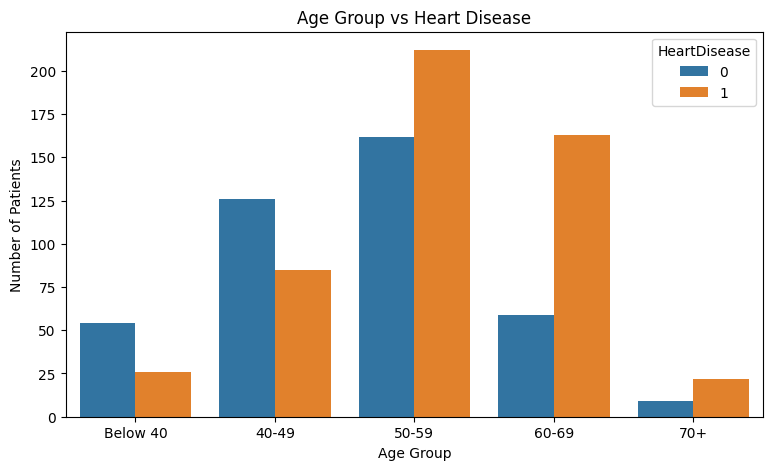

In [195]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df_clean, x="AgeGroup", hue="HeartDisease")
plt.title("Age Group vs Heart Disease")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.show()

##### Older age groups contain a larger share of patients with heart disease compared with younger groups.

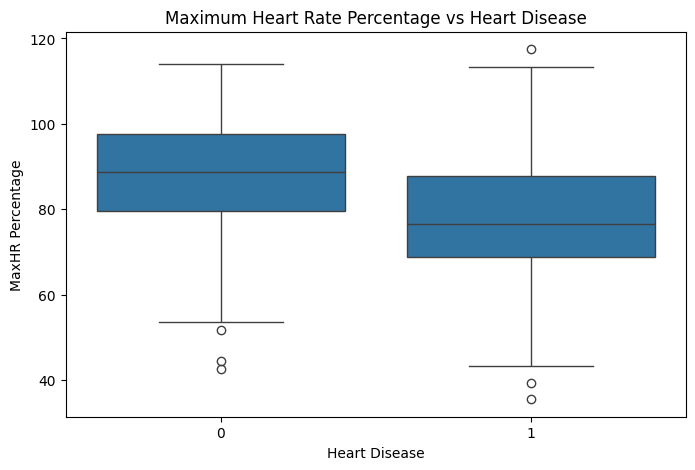

In [196]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="HeartDisease", y="MaxHR_Percent")
plt.title("Maximum Heart Rate Percentage vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("MaxHR Percentage")
plt.show()

##### The distribution of maximum heart rate percentage differs between the two heart disease groups.

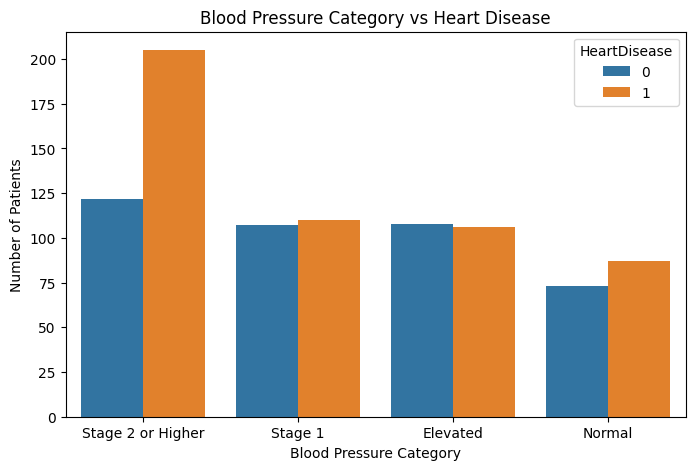

In [197]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="BPCategory", hue="HeartDisease")
plt.title("Blood Pressure Category vs Heart Disease")
plt.xlabel("Blood Pressure Category")
plt.ylabel("Number of Patients")
plt.show()

##### The number of patients with heart disease varies across blood pressure categories

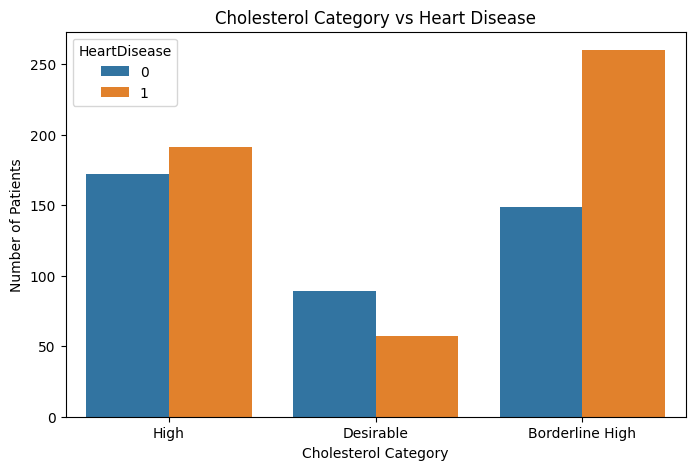

In [198]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="CholesterolCategory", hue="HeartDisease")
plt.title("Cholesterol Category vs Heart Disease")
plt.xlabel("Cholesterol Category")
plt.ylabel("Number of Patients")
plt.show()

##### The distribution of heart disease differs across cholesterol categories.

In [199]:
df_clean[[
    "Age", "AgeGroup",
    "RestingBP", "BPCategory",
    "Cholesterol", "CholesterolCategory",
    "MaxHR", "MaxHR_Percent"
]].head()

,Age,AgeGroup,RestingBP,BPCategory,Cholesterol,CholesterolCategory,MaxHR,MaxHR_Percent
0,40,40-49,140.0,Stage 2 or Higher,289.0,High,172,95.555556
1,49,40-49,160.0,Stage 2 or Higher,180.0,Desirable,156,91.228070
2,37,Below 40,130.0,Stage 1,283.0,High,98,53.551913
3,48,40-49,138.0,Stage 1,214.0,Borderline High,108,62.790698
4,54,50-59,150.0,Stage 2 or Higher,195.0,Desirable,122,73.493976


## One-Hot Encoding

In [200]:
categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "AgeGroup",
    "BPCategory",
    "CholesterolCategory"
]
df_model = pd.get_dummies( df_clean, columns=categorical_features, drop_first=True, dtype=int)
df_model.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,MaxHR_Percent,Sex_M,ChestPainType_ATA,...,ST_Slope_Up,AgeGroup_40-49,AgeGroup_50-59,AgeGroup_60-69,AgeGroup_70+,BPCategory_Normal,BPCategory_Stage 1,BPCategory_Stage 2 or Higher,CholesterolCategory_Desirable,CholesterolCategory_High
0,40,140.0,289.0,0,172,0.0,0,95.555556,1,1,...,1,1,0,0,0,0,0,1,0,1
1,49,160.0,180.0,0,156,1.0,1,91.228070,0,0,...,0,1,0,0,0,0,0,1,1,0
2,37,130.0,283.0,0,98,0.0,0,53.551913,1,1,...,1,0,0,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,62.790698,0,0,...,0,1,0,0,0,0,1,0,0,0
4,54,150.0,195.0,0,122,0.0,0,73.493976,1,0,...,1,0,1,0,0,0,0,1,1,0


## Final Validation

In [201]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Model-ready shape:", df_model.shape)

Original shape: (918, 12)
Cleaned shape: (918, 16)
Model-ready shape: (918, 26)


In [202]:
print("Total missing values:", df_model.isnull().sum().sum())
print("Duplicate rows:", df_model.duplicated().sum())
print("HeartDisease counts:")
print(df_model["HeartDisease"].value_counts())

Total missing values: 0
Duplicate rows: 0
HeartDisease counts:
HeartDisease
1    508
0    410
Name: count, dtype: int64


In [203]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            918 non-null    int64  
 1   RestingBP                      918 non-null    float64
 2   Cholesterol                    918 non-null    float64
 3   FastingBS                      918 non-null    int64  
 4   MaxHR                          918 non-null    int64  
 5   Oldpeak                        918 non-null    float64
 6   HeartDisease                   918 non-null    int64  
 7   MaxHR_Percent                  918 non-null    float64
 8   Sex_M                          918 non-null    int64  
 9   ChestPainType_ATA              918 non-null    int64  
 10  ChestPainType_NAP              918 non-null    int64  
 11  ChestPainType_TA               918 non-null    int64  
 12  RestingECG_Normal              918 non-null    int64  
 13  R